# Eksperyment Bayes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

In [ ]:
def make_data(llambda, n_samples):
    return np.random.exponential(scale=1/llambda, size=n_samples)

# Metoda maksymalnej wiarygodności

### Pojedyncza estymacja

In [ ]:
def f_wiar(llambda, x_data):
    return np.prod([llambda*np.exp(-llambda*x) for x in x_data])


37624.81603559183

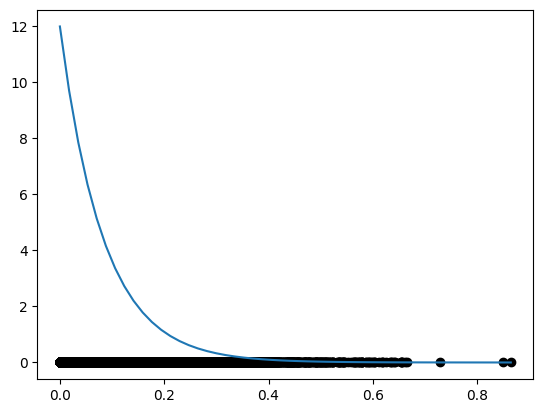

Optimization terminated successfully.
         Current function value: -44374.535252
         Iterations: 18
         Function evaluations: 36
Lambda prawdziwe = 12.0000
Lambda szacowane = 11.9311
Lambda liczone numerycznie 1 = 11.9312
Lambda liczone numerycznie 2 = 8.1253


In [ ]:
# --------- parametry zadania
llambda = 12
n_samples = 30000
# ---------------------------

# generuję dane
x_data = make_data(llambda, n_samples)


fig, ax = plt.subplots(nrows=1,ncols=1)

# rysuję punkty danych
ax.scatter(x_data, np.zeros_like(x_data), c='black')

# rysuję funkcję gęstości
x_axis = np.linspace(0, max(x_data))
ax.plot(x_axis, llambda*np.exp(-llambda*x_axis))

plt.show()

# "Uczenie" modelu wzorem analitycznym
llambda_est = 1 / x_data.mean()

# "Uczenie" modelu procedurą numeryczną wersja 1
# def f_wiar(llambda, x_data):
#     return np.prod([llambda*np.exp(-llambda*x) for x in x_data])
# def lod_f_wiar(llambda, x_data):
#     return - np.sum([np.log(llambda*np.exp(-llambda*x)) for x in x_data])

llambda_est_num1 = np.random.uniform(0,1)+0.00001 +7
n = x_data.size
s = x_data.sum()

def nll(lmb):                       # NLL = –logL
    if lmb <= 0:                    # λ musi być >0
        return np.inf
    return -( n*np.log(lmb) - lmb*s )

wynik = opt.fmin(nll, llambda_est_num1)

# "Uczenie" modelu procedurą numeryczną wersja 2
llambda_est_num = np.random.uniform(0,1)+0.00001 +7
n = x_data.size
s = x_data.sum()

def grad_nll(llambda):
    return -n / llambda + s

for r in range(10000):
    llambda_est_num2 = llambda_est_num - 0.5 * grad_nll(llambda_est_num)
    if llambda_est_num2 <= 0:
      llambda_est_num2 = llambda_est_num * 0.5
    if abs(llambda_est_num2-llambda_est_num) < 1e-9:
        break
    llambda_est_num = llambda_est_num2

print(f'Lambda prawdziwe = {llambda:0.4f}')
print(f'Lambda szacowane = {llambda_est:0.4f}')
print(f'Lambda liczone numerycznie 1 = {wynik[0]:0.4f}')
print(f'Lambda liczone numerycznie 2 = {llambda_est_num:0.4f}')

### Wielokrotna estymacja przy tej samej wartości $\lambda$

In [ ]:
# --------- parametry zadania
llambda = 12
n_samples = 3000
n_trials = 10
# ---------------------------



print(f'Lambda prawdziwe = {llambda:0.4f}')

oszacowania = []
oszacowania2 = []
for i in range(n_trials):

    # generuję dane
    x_data = make_data(llambda, n_samples)

    # "Uczenie" modelu wzorem analitycznym
    llambda_est = 1 / x_data.mean()
    oszacowania.append(llambda_est)
    print(f'Lambda szacowane w podejściu nr {i+1} = {llambda_est:0.4f}')

    # "Uczenie" modelu wzorem num
    llambda_est_num1 = np.random.uniform(0,1)+0.00001 +7
    n = x_data.size
    s = x_data.sum()

    def nll(lmb):                       # NLL = –logL
        if lmb <= 0:                    # λ musi być >0
            return np.inf
        return -( n*np.log(lmb) - lmb*s )

    wynik = opt.fmin(nll, llambda_est_num1)
    oszacowania2.append(wynik[0])
    print(f'Lambda szacowane numerycznie w podejściu nr {i+1} = {wynik[0]:0.4f}')

oszacowania = np.array(oszacowania)
oszacowania2 = np.array(oszacowania2)

print()
print(f'Średnia z oszacowań analitycz. = {oszacowania.mean():0.4f}')
print(f'Odch. stand z oszacowań analitycz.= {oszacowania.std():0.4f}')

print(f'Średnia z oszacowań num. = {oszacowania2.mean():0.4f}')
print(f'Odch. stand z oszacowańnum. = {oszacowania2.std():0.4f}')

Lambda prawdziwe = 12.0000
Lambda szacowane w podejściu nr 1 = 11.7957
Optimization terminated successfully.
         Current function value: -4403.213996
         Iterations: 18
         Function evaluations: 36
Lambda szacowane numerycznie w podejściu nr 1 = 11.7958
Lambda szacowane w podejściu nr 2 = 12.1422
Optimization terminated successfully.
         Current function value: -4490.055021
         Iterations: 18
         Function evaluations: 36
Lambda szacowane numerycznie w podejściu nr 2 = 12.1422
Lambda szacowane w podejściu nr 3 = 11.9993
Optimization terminated successfully.
         Current function value: -4454.554221
         Iterations: 19
         Function evaluations: 38
Lambda szacowane numerycznie w podejściu nr 3 = 11.9994
Lambda szacowane w podejściu nr 4 = 11.7759
Optimization terminated successfully.
         Current function value: -4398.173596
         Iterations: 18
         Function evaluations: 36
Lambda szacowane numerycznie w podejściu nr 4 = 11.7759
Lambd

In [1]:
class ExpMLEOnline:
    def __init__(self):
        self.n = 0         # liczba obserwacji
        self.s = 0.0       # suma x
        self.lmb = np.nan  # bieżące λ̂

    def update(self, x):
        """Przetwórz pojedynczą obserwację x."""
        self.n += 1
        self.s += x
        self.lmb = self.n / self.s

    def estimate(self):
        return self.lmb
    
est = ExpMLEOnline()
for x in x_data:          # strumień danych
    est.update(x)
    # w dowolnym momencie:
    print("λ̂ =", est.estimate())

NameError: name 'np' is not defined

# Metoda Bayesa

Parametr $\lambda$ reprezentuje pewien proces generujący dane.

Tym razem $\lambda$ nie jest podawane "z palca", ale będzie losowane z "worka możliwych procesów".

Ekspert oświadcza mi, że $\lambda$ ma rozkład ... o parametrach równych ... .

Mogę mu ufać albo nie.

In [ ]:
def make_lambda(m_lambda, sigma_lambda, n_processes):
    return np.random.normal(m_lambda, sigma_lambda, size=n_processes)

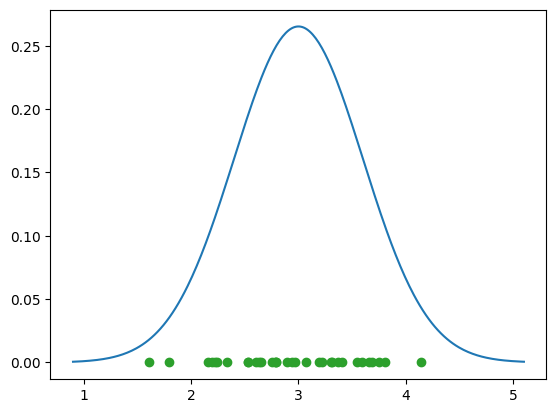

In [ ]:
# --------- parametry zadania
n_samples = 30
n_trials = 10
# dla potrzeb metody Bayesa
n_processes = 33
# rozkład a'priori dla parametru lambda
m_lambda = 3
sigma_lambda = 0.6
# ---------------------------

# generuję procesy
lambda_data = make_lambda(m_lambda, sigma_lambda, n_processes)

fig, ax = plt.subplots(nrows=1,ncols=1)

# rysuję punkty danych
ax.scatter(lambda_data, np.zeros_like(lambda_data), c='tab:green')

# rysuję funkcję gęstości
lambda_axis = np.linspace(m_lambda-3.5*sigma_lambda, m_lambda+3.5*sigma_lambda, num=300)
ax.plot(lambda_axis, np.exp(-((lambda_axis-m_lambda)/sigma_lambda)**2/2)/(2*np.pi*sigma_lambda))

plt.show()

In [ ]:
# --------- parametry zadania
n_samples = 30
n_trials = 10
# ---------------------------

llambda = np.random.choice(lambda_data, size = 100)
llambda = llambda.mean()

print()
print(f'Lambda oczekiwana z worka = {m_lambda:0.4f}')
print(f'Lambda aktualne = {llambda:0.4f}')
print()

oszacowania = []
oszacowania2 = []
for i in range(n_trials):

    # generuję dane
    x_data = make_data(llambda, n_samples)

    # "Uczenie" modelu wzorem analitycznym
    llambda_est = 1 / x_data.mean()
    oszacowania.append(llambda_est)
    print(f'Lambda szacowane w podejściu nr {i+1} = {llambda_est:0.4f}')


    # "Uczenie" modelu wzorem num
    llambda_est_num1 = np.random.uniform(0,1)+0.00001 +7
    n = x_data.size
    s = x_data.sum()

    def nll(lmb):                       # NLL = –logL
        if lmb <= 0:                    # λ musi być >0
            return np.inf
        return -( n*np.log(lmb) - lmb*s )

    wynik = opt.fmin(nll, llambda_est_num1)
    oszacowania2.append(wynik[0])
    print(f'Lambda szacowane numerycznie w podejściu nr {i+1} = {wynik[0]:0.4f}')

oszacowania = np.array(oszacowania)
oszacowania2 = np.array(oszacowania2)

print()
print(f'Średnia z oszacowań analitycz. = {oszacowania.mean():0.4f}')
print(f'Odch. stand z oszacowań analitycz.= {oszacowania.std():0.4f}')

print(f'Średnia z oszacowań num. = {oszacowania2.mean():0.4f}')
print(f'Odch. stand z oszacowańnum. = {oszacowania2.std():0.4f}')



Lambda oczekiwana z worka = 3.0000
Lambda aktualne = 2.9518

Lambda szacowane w podejściu nr 1 = 2.8175
Optimization terminated successfully.
         Current function value: -1.075172
         Iterations: 19
         Function evaluations: 38
Lambda szacowane numerycznie w podejściu nr 1 = 2.8175
Lambda szacowane w podejściu nr 2 = 2.3781
Optimization terminated successfully.
         Current function value: 4.010330
         Iterations: 19
         Function evaluations: 38
Lambda szacowane numerycznie w podejściu nr 2 = 2.3781
Lambda szacowane w podejściu nr 3 = 2.7207
Optimization terminated successfully.
         Current function value: -0.027205
         Iterations: 19
         Function evaluations: 38
Lambda szacowane numerycznie w podejściu nr 3 = 2.7207
Lambda szacowane w podejściu nr 4 = 2.7099
Optimization terminated successfully.
         Current function value: 0.092214
         Iterations: 19
         Function evaluations: 38
Lambda szacowane numerycznie w podejściu nr 4 =